# Data Clustering

## 1. Import Libraries

In [47]:
import importlib
import sys, os

# Ensure project root is on path
sys.path.insert(0, os.path.abspath(".."))

import src.code.class_pipeline_functions as cpf
import src.code.io_utils as io

importlib.reload(cpf)
importlib.reload(io)

import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 1000)

## 2. Multiple Perspective Approach

 **Approach:** K-Means clustering applied independently across three business perspectives, 
 followed by hierarchical merging of the resulting cluster combinations.

In [39]:
customer = io.load("../data/prepared/customer.parquet")

[LOAD] ../data/prepared/customer.parquet | shape: (136446, 44)


In [40]:
# Perspective 1 — Contract Financial Profile
p1_cols = ['N_CONTRACTS', 'TOTAL_MTFINO', 
           'TOTAL_MENSALIDADE', 'MEDIAN_RESSO', 'MT_MENSAL_MEDIAN']

# Perspective 2 — Risk & External Credit Behaviour
p2_cols = ['MAX_RANGPRO', 'MAX_RANGCLI', 'MEDIAN_DURDEG', 
           'ALLBD_IDADE_MEAN__N', 'ALLBD_A_CL__N', 'ALLBD_A_CP__N',
           'COUNT_CL_MEDIAN', 'COUNT_AUTO_MEDIAN', 'COUNT_TOTAL_MEDIAN',
           'DIVIDAS_CL_MEDIAN', 'DIVIDAS_CP_MEDIAN', 
           'DIVIDAS_AUTO_MEDIAN', 'DIVIDAS_HT_MEDIAN',
           'MONTVENC_CL_MAX', 'MONTVENC_CP_MAX', 
           'MONTVENC_AUTO_MAX', 'MONTVENC_HT_MAX']  # ALTERAR

# Perspective 3 — Cetelem History
p3_cols = ['CLIENT_SENIORITY_YEARS', 'MONTHS_SINCE_LAST_CONTRACT', 
           'ALLBD_N_Dossiers__N']

profiling_cols = ['sdem_age', 'CSP', 'NBENF', 'SITFAM', 'HABITAT']

Three perspectives were defined to capture distinct dimensions of customer behaviour:

**Perspective 1 — Contract Financial Profile**  
Captures the financial weight of the customer's relationship with Cetelem.  
Variables: `N_CONTRACTS`, `TOTAL_MTFINO`, `TOTAL_MENSALIDADE`, `MEDIAN_RESSO`, `MT_MENSAL_MEDIAN`

**Perspective 2 — Risk & External Credit Behaviour** ⚠️  
Captures the customer's broader credit behaviour and delinquency signals.  
Variables: `MAX_RANGPRO`, `MAX_RANGCLI`, `MEDIAN_DURDEG`, `ALLBD_IDADE_MEAN__N`, ...  
> ⚠️ **Note:** `MONTVENC_*` variables had IQR=0 (75%+ zeros). Log1p transform + flag encoding applied. To validate with team.

**Perspective 3 — Cetelem History**  
Captures the depth and recency of the customer's history within Cetelem.  
Variables: `CLIENT_SENIORITY_YEARS`, `MONTHS_SINCE_LAST_CONTRACT`, `ALLBD_N_Dossiers__N`  
> ⚠️ **Note:** Data limited to 2024–2025 window. Seniority and recency metrics reflect relative position within the dataset period, not true customer lifetime.

In [41]:
perspectives = {
    'P1_Financial': p1_cols,
    'P2_Risk': p2_cols,
    'P3_History': p3_cols
}

### 2.1 N-Clusters

Determining the optimal number of clusters for each perspective using two complementary methods:

- **Elbow Method**: identifies the point of diminishing returns in inertia reduction
- **Silhouette Score**: measures how well-separated clusters are (range: -1 to 1)

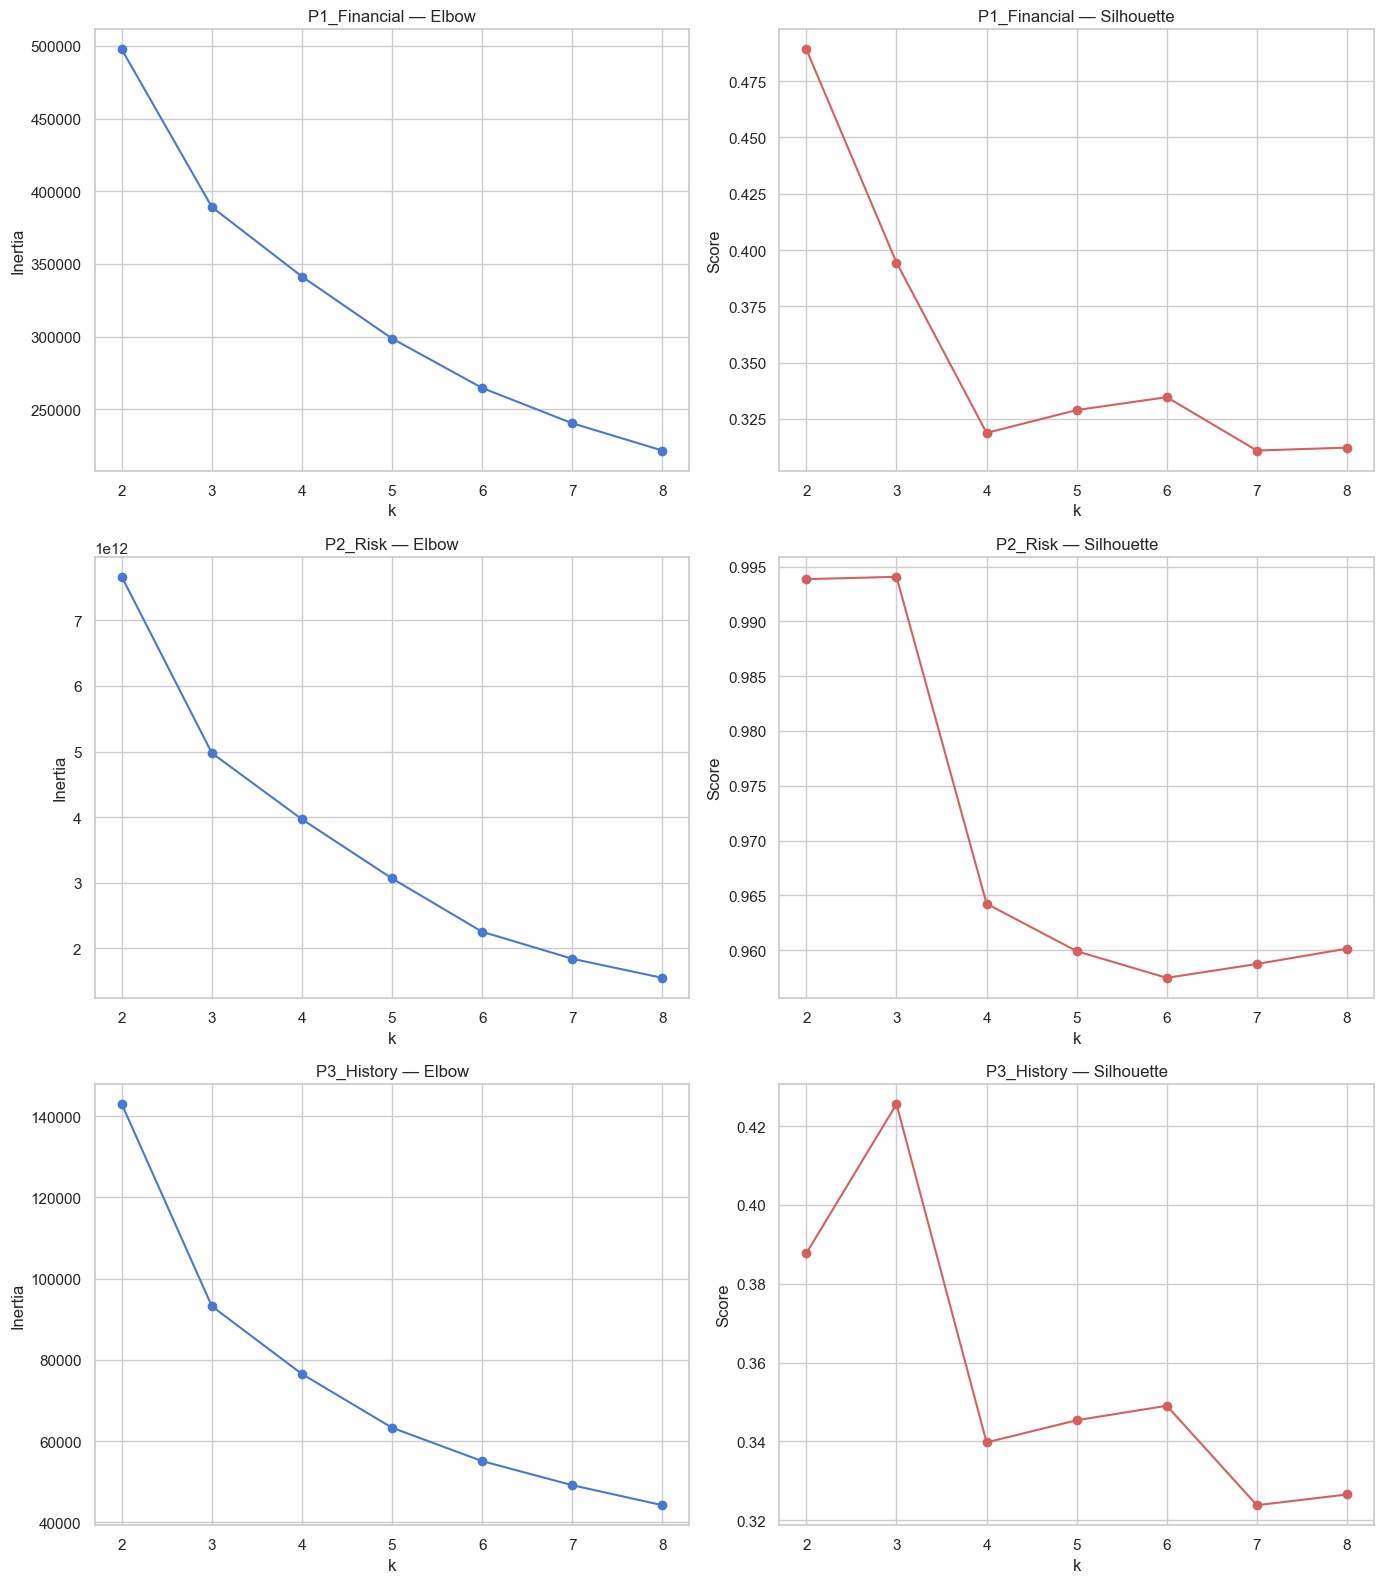

In [30]:
fig, axes = plt.subplots(len(perspectives), 2, figsize=(14, 16))

for idx, (name, cols) in enumerate(perspectives.items()):
    X = customer[cols].dropna()
    inertias, silhouettes = [], []
    K = range(2, 9)
    
    for k in K:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, km.labels_, sample_size=10000))
    
    axes[idx, 0].plot(K, inertias, 'bo-')
    axes[idx, 0].set_title(f'{name} — Elbow')
    axes[idx, 0].set_xlabel('k')
    axes[idx, 0].set_ylabel('Inertia')
    
    axes[idx, 1].plot(K, silhouettes, 'ro-')
    axes[idx, 1].set_title(f'{name} — Silhouette')
    axes[idx, 1].set_xlabel('k')
    axes[idx, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()

| Perspective | k | Notes |
|-------------|---|-------|
| P1 — Financial Profile | 3 | Elbow + Silhouette agree |
| P2 — Risk & External Credit |  3 | MONTVENC scaling issue — to review |
| P3 — Cetelem History | 3 | Clear peak at k=3 |

In [42]:
perspectives = {
    'P1_Financial': {'cols': p1_cols, 'k': 3},
    'P2_Risk':      {'cols': p2_cols, 'k': 3},  # ← k a confirmar amanhã
    'P3_History':   {'cols': p3_cols, 'k': 3},
}

### 2.2 K-means Clustering

In [ ]:
for name, config in perspectives.items():
    cols = config['cols']
    k    = config['k']
    
    print(f"\n{'='*50}", flush=True)
    print(f"{name} | k={k} | {len(cols)} variáveis", flush=True)
    print(f"{'='*50}", flush=True)
    
    # Verificar nulos
    n_nulls = customer[cols].isnull().sum().sum()
    if n_nulls > 0:
        print(f"  {n_nulls} nulos encontrados — a remover linhas", flush=True)
    
    X = customer[cols].dropna()
    
    # Fit KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    
    # Guardar labels no dataframe
    cluster_col = f'cluster_{name}'
    customer.loc[X.index, cluster_col] = labels
    
    # Distribuição dos clusters
    dist = customer[cluster_col].value_counts().sort_index()
    print("\nDistribuição dos clusters:", flush=True)
    for cluster, count in dist.items():
        pct = count / len(X) * 100
        print(f"  Cluster {int(cluster)}: {count:>6} clientes ({pct:.1f}%)", flush=True)
    
    # Centroides — logo aqui para não perder output
    print("\nCentroides:", flush=True)
    centroids = customer.dropna(subset=[cluster_col]).groupby(cluster_col)[cols].mean().round(3)
    print(centroids.T.to_string(), flush=True)
    
    # Inércia final
    print(f"\nInércia final: {km.inertia_:,.0f}", flush=True)
    print(flush=True)
    sys.stdout.flush()

print("\n Clustering concluído para todas as perspetivas")
print(f"Colunas adicionadas: {[f'cluster_{p}' for p in perspectives.keys()]}")


P1_Financial | k=3 | 5 variáveis

Distribuição dos clusters:
  Cluster 0:  90806 clientes (66.6%)
  Cluster 1:  26927 clientes (19.7%)
  Cluster 2:  18713 clientes (13.7%)

Centroides:
cluster_P1_Financial  0.000  1.000  2.000
N_CONTRACTS           0.098  0.649  0.203
TOTAL_MTFINO         -0.125  1.473  0.476
TOTAL_MENSALIDADE    -0.134  1.480  0.459
MEDIAN_RESSO          0.018  0.407  0.714
MT_MENSAL_MEDIAN      0.259  0.347  3.994

Inércia final: 389,126


P2_Risk | k=3 | 17 variáveis

Distribuição dos clusters:
  Cluster 0: 135937 clientes (99.6%)
  Cluster 1:    484 clientes (0.4%)
  Cluster 2:     25 clientes (0.0%)

Centroides:
cluster_P2_Risk      0.000      1.000      2.000
MAX_RANGPRO          0.107      0.241      0.349
MAX_RANGCLI          0.099      0.123      0.234
MEDIAN_DURDEG       -0.340     -0.393      0.109
ALLBD_IDADE_MEAN__N  0.070      0.714      0.299
ALLBD_A_CL__N       -0.209     -0.998     -0.247
ALLBD_A_CP__N       -0.303     -0.996     -0.757
COUNT_CL_MEDIA

In [45]:
# ── Merge dos clusters ────────────────────────────────────────────────────────
cluster_cols = ['cluster_P1_Financial', 'cluster_P2_Risk', 'cluster_P3_History']

# Converter para int (podem estar como float após o loc assignment)
for col in cluster_cols:
    customer[col] = customer[col].fillna(-1).astype(int)

# Criar label combinada
customer['cluster_combined'] = (
    customer['cluster_P1_Financial'].astype(str) + '_' +
    customer['cluster_P2_Risk'].astype(str) + '_' +
    customer['cluster_P3_History'].astype(str)
)

# Ver distribuição das combinações
print("Distribuição das combinações (P1_P2_P3):")
combo_dist = customer['cluster_combined'].value_counts().sort_values(ascending=False)
print(combo_dist)
print(f"\nTotal combinações com clientes: {len(combo_dist)}")
print(f"Total combinações possíveis:    27")

Distribuição das combinações (P1_P2_P3):
cluster_combined
0_0_0    52247
0_0_2    27086
1_0_0    14018
0_0_1    11042
2_0_0     8450
1_0_2     7256
2_0_2     6347
1_0_1     5584
2_0_1     3907
0_1_2      396
1_1_2       61
0_1_1       17
0_2_0        9
0_2_2        6
1_1_1        5
2_2_1        3
2_2_2        3
0_1_0        2
1_2_0        1
2_1_2        1
0_2_1        1
2_1_1        1
1_1_0        1
2_2_0        1
1_2_1        1
Name: count, dtype: int64

Total combinações com clientes: 25
Total combinações possíveis:    27


In [46]:
# Merge das 3 perspetivas
customer['cluster_P1_P2_P3'] = (
    customer['cluster_P1_Financial'].astype(str) + '_' +
    customer['cluster_P2_Risk'].astype(str) + '_' +
    customer['cluster_P3_History'].astype(str)
)

# Distribuição completa
print("Distribuição P1 x P2 x P3:")
print(f"{'Combo':<12} {'P1':>4} {'P2':>4} {'P3':>4} {'Clientes':>10} {'%':>6}")
print("-" * 45)

combo = customer['cluster_P1_P2_P3'].value_counts().sort_values(ascending=False)
for label, count in combo.items():
    pct = count / len(customer) * 100
    p1, p2, p3 = label.split('_')
    print(f"  {label:<12} {p1:>4} {p2:>4} {p3:>4} {count:>10,} ({pct:>5.1f}%)")

print(f"\nTotal combinações com clientes: {len(combo)}")
print(f"Total combinações possíveis:    27")

# Separar combinações relevantes vs marginais (P2 ainda com problema)
print("\n── Combinações principais (P2=0, 99.6% dos clientes) ──")
main = customer[customer['cluster_P2_Risk'] == 0]['cluster_P1_P2_P3'].value_counts()
for label, count in main.items():
    pct = count / len(customer) * 100
    print(f"  {label:<12} {count:>10,} ({pct:>5.1f}%)")

print("\n── Combinações marginais (P2=1 ou P2=2) — a rever amanhã ──")
marginal = customer[customer['cluster_P2_Risk'] != 0]['cluster_P1_P2_P3'].value_counts()
for label, count in marginal.items():
    pct = count / len(customer) * 100
    print(f"  {label:<12} {count:>10,} ({pct:>5.1f}%)")

Distribuição P1 x P2 x P3:
Combo          P1   P2   P3   Clientes      %
---------------------------------------------
  0_0_0           0    0    0     52,247 ( 38.3%)
  0_0_2           0    0    2     27,086 ( 19.9%)
  1_0_0           1    0    0     14,018 ( 10.3%)
  0_0_1           0    0    1     11,042 (  8.1%)
  2_0_0           2    0    0      8,450 (  6.2%)
  1_0_2           1    0    2      7,256 (  5.3%)
  2_0_2           2    0    2      6,347 (  4.7%)
  1_0_1           1    0    1      5,584 (  4.1%)
  2_0_1           2    0    1      3,907 (  2.9%)
  0_1_2           0    1    2        396 (  0.3%)
  1_1_2           1    1    2         61 (  0.0%)
  0_1_1           0    1    1         17 (  0.0%)
  0_2_0           0    2    0          9 (  0.0%)
  0_2_2           0    2    2          6 (  0.0%)
  1_1_1           1    1    1          5 (  0.0%)
  2_2_1           2    2    1          3 (  0.0%)
  2_2_2           2    2    2          3 (  0.0%)
  0_1_0           0    1    0  

### 2.3 Merge clusters with Hierarchical Clustering

Each customer receives a combined label `P1_P2_P3` (e.g. `0_0_2`) from the three K-Means runs.  
Ward linkage hierarchical clustering is then applied over the centroids of each combination  
to identify natural groupings and reduce to a final set of actionable segments.


Centroides calculados para 25 combinações
                  N_CONTRACTS  TOTAL_MTFINO  TOTAL_MENSALIDADE  MEDIAN_RESSO  MT_MENSAL_MEDIAN  MAX_RANGPRO  MAX_RANGCLI  MEDIAN_DURDEG  ALLBD_IDADE_MEAN__N  ALLBD_A_CL__N  ALLBD_A_CP__N  COUNT_CL_MEDIAN  COUNT_AUTO_MEDIAN  COUNT_TOTAL_MEDIAN  DIVIDAS_CL_MEDIAN  DIVIDAS_CP_MEDIAN  DIVIDAS_AUTO_MEDIAN  DIVIDAS_HT_MEDIAN  MONTVENC_CL_MAX  MONTVENC_CP_MAX  MONTVENC_AUTO_MAX  MONTVENC_HT_MAX  CLIENT_SENIORITY_YEARS  MONTHS_SINCE_LAST_CONTRACT  ALLBD_N_Dossiers__N
cluster_P1_P2_P3                                                                                                                                                                                                                                                                                                                                                                                                                                                               
0_0_0                   0.116 

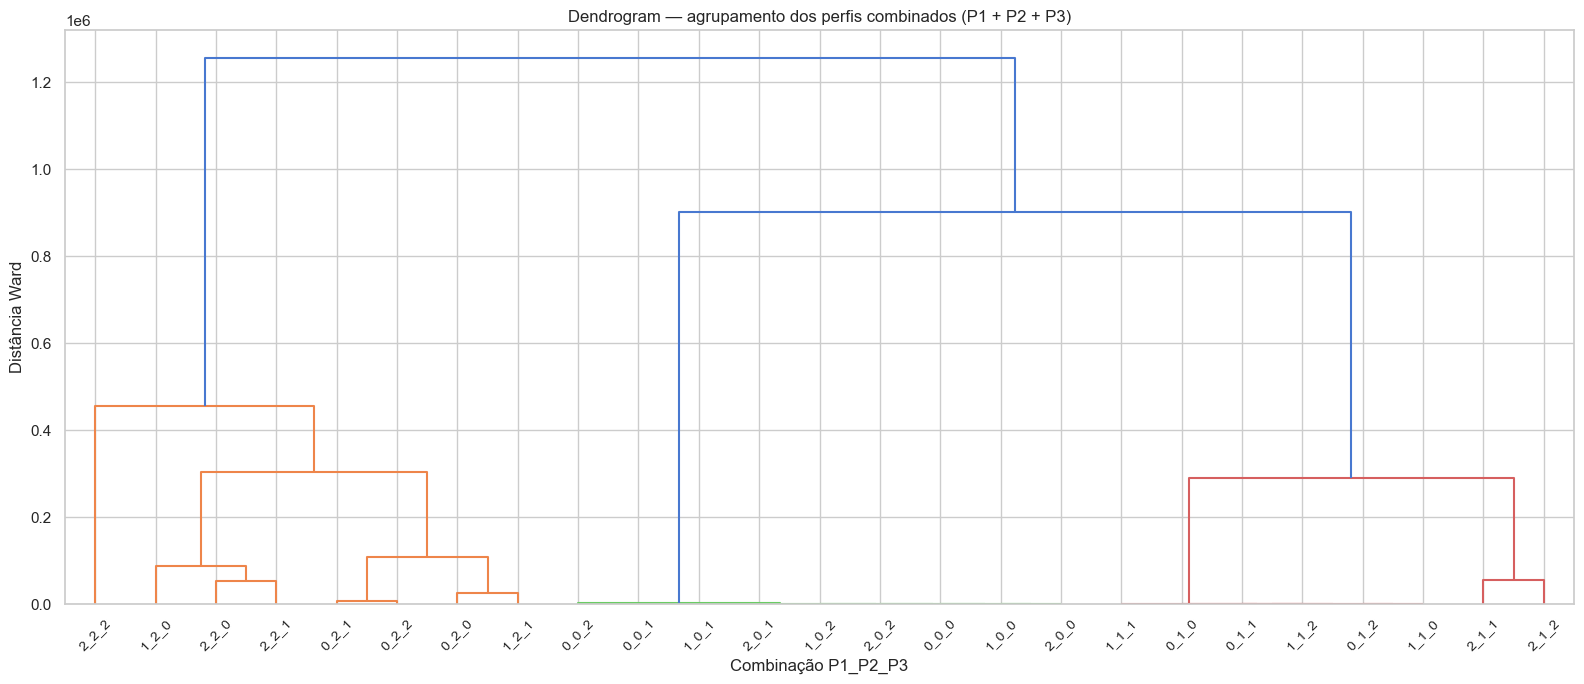

In [50]:
# ── Calcular centroides de cada combinação ────────────────────────────────────
all_cols = p1_cols + p2_cols + p3_cols

centroids = customer.groupby('cluster_P1_P2_P3')[all_cols].mean()
print(f"Centroides calculados para {len(centroids)} combinações")
print(centroids.round(3).to_string())

# ── Hierarchical clustering sobre os centroides ───────────────────────────────
Z = linkage(centroids, method='ward')

# Dendrogram
fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(Z, labels=centroids.index.tolist(), ax=ax,
           leaf_rotation=45, leaf_font_size=10)
ax.set_title('Dendrogram — agrupamento dos perfis combinados (P1 + P2 + P3)')
ax.set_xlabel('Combinação P1_P2_P3')
ax.set_ylabel('Distância Ward')
plt.tight_layout()
plt.show()

In [51]:
# ── Após ver o dendrogram, cortar em n grupos ─────────────────────────────────
# AJUSTA este valor depois de veres o dendrogram
n_grupos_finais = 4

labels_hier = fcluster(Z, n_grupos_finais, criterion='maxclust')

# Mapear cada combinação ao grupo final
combo_to_grupo = dict(zip(centroids.index, labels_hier))
customer['cluster_final'] = customer['cluster_P1_P2_P3'].map(combo_to_grupo)

print(f"\nMapeamento combinações → grupo final (n={n_grupos_finais}):")
print(f"{'Combo':<12} {'Grupo':>6} {'Clientes':>10} {'%':>6}")
print("-" * 38)
for combo, grupo in sorted(combo_to_grupo.items(), key=lambda x: x[1]):
    count = (customer['cluster_P1_P2_P3'] == combo).sum()
    pct = count / len(customer) * 100
    print(f"  {combo:<12} {grupo:>6} {count:>10,} ({pct:>5.1f}%)")

# Distribuição dos grupos finais
print(f"\nDistribuição dos grupos finais:")
print(f"{'Grupo':>6} {'Clientes':>10} {'%':>6}")
print("-" * 25)
for grupo, count in customer['cluster_final'].value_counts().sort_index().items():
    pct = count / len(customer) * 100
    print(f"  {int(grupo):>6} {count:>10,} ({pct:>5.1f}%)")


Mapeamento combinações → grupo final (n=4):
Combo         Grupo   Clientes      %
--------------------------------------
  0_2_0             1          9 (  0.0%)
  0_2_1             1          1 (  0.0%)
  0_2_2             1          6 (  0.0%)
  1_2_0             1          1 (  0.0%)
  1_2_1             1          1 (  0.0%)
  2_2_0             1          1 (  0.0%)
  2_2_1             1          3 (  0.0%)
  2_2_2             2          3 (  0.0%)
  0_0_0             3     52,247 ( 38.3%)
  0_0_1             3     11,042 (  8.1%)
  0_0_2             3     27,086 ( 19.9%)
  1_0_0             3     14,018 ( 10.3%)
  1_0_1             3      5,584 (  4.1%)
  1_0_2             3      7,256 (  5.3%)
  2_0_0             3      8,450 (  6.2%)
  2_0_1             3      3,907 (  2.9%)
  2_0_2             3      6,347 (  4.7%)
  0_1_0             4          2 (  0.0%)
  0_1_1             4         17 (  0.0%)
  0_1_2             4        396 (  0.3%)
  1_1_0             4          1 (  0.

## 3. Profiling


PROFILING — P1_Financial

── Distribuição ──
  Cluster 0:   90,806 (66.6%)
  Cluster 1:   26,927 (19.7%)
  Cluster 2:   18,713 (13.7%)

── Centroides (variáveis de clustering) ──
cluster_P1_Financial      0     1     2
N_CONTRACTS           0.098 0.649 0.203
TOTAL_MTFINO         -0.125 1.473 0.476
TOTAL_MENSALIDADE    -0.134 1.480 0.459
MEDIAN_RESSO          0.018 0.407 0.714
MT_MENSAL_MEDIAN      0.259 0.347 3.994

── Perfil contínuo (médias) ──
                           Cluster 0  Cluster 1  Cluster 2
-------------------------------------------------------------
  sdem_age                     -0.07      -0.05       0.62
  NBENF                         0.61       0.67       0.54
  CSP                          -0.27      -0.35      -0.39

── Situação Familiar (% por cluster) ──
cluster_P1_Financial      0      1      2
sdem_SITFAM_D         5.600  5.800 11.500
sdem_SITFAM_F         2.400  2.300  1.200
sdem_SITFAM_P         2.100  2.000  1.400
sdem_SITFAM_S        20.500 20.300  7.700

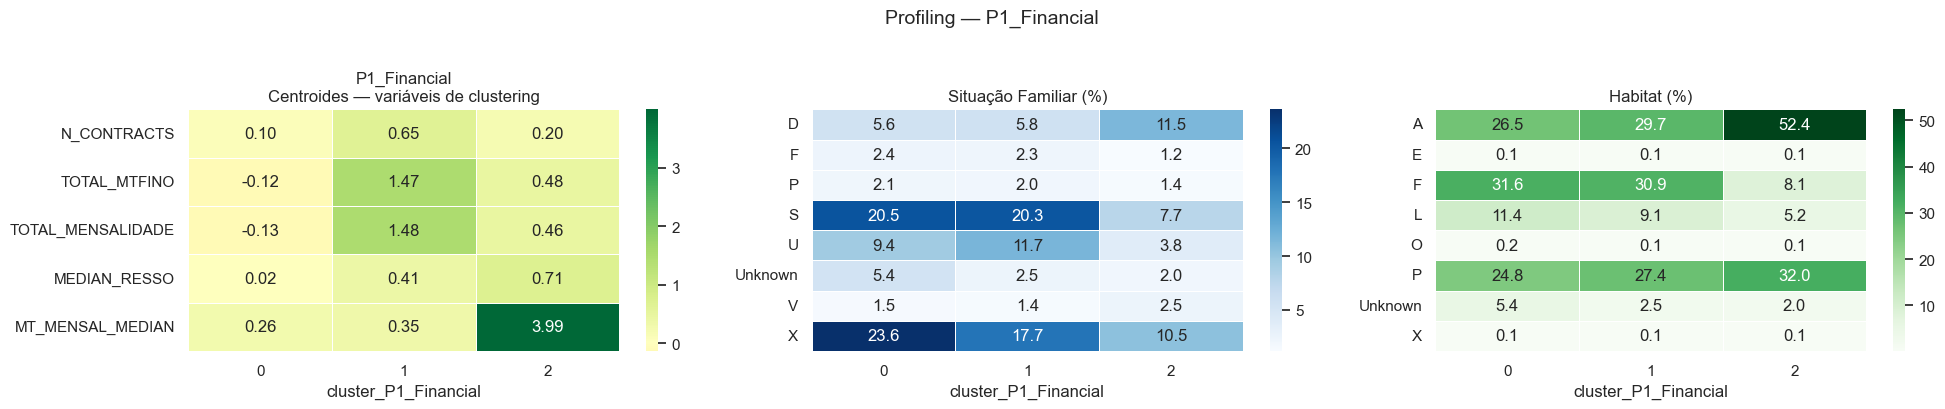


PROFILING — P2_Risk

── Distribuição ──
  Cluster 0:  135,937 (99.6%)
  Cluster 1:      484 (0.4%)
  Cluster 2:       25 (0.0%)

── Centroides (variáveis de clustering) ──
cluster_P2_Risk          0          1          2
MAX_RANGPRO          0.107      0.241      0.349
MAX_RANGCLI          0.099      0.123      0.234
MEDIAN_DURDEG       -0.340     -0.393      0.109
ALLBD_IDADE_MEAN__N  0.070      0.714      0.299
ALLBD_A_CL__N       -0.209     -0.998     -0.247
ALLBD_A_CP__N       -0.303     -0.996     -0.757
COUNT_CL_MEDIAN      0.546      0.835      2.320
COUNT_AUTO_MEDIAN    0.530      0.517      0.360
COUNT_TOTAL_MEDIAN  -0.005     -0.039      1.330
DIVIDAS_CL_MEDIAN    0.320     16.633      2.250
DIVIDAS_CP_MEDIAN    0.415     33.619      1.341
DIVIDAS_AUTO_MEDIAN  0.626      0.951      0.427
DIVIDAS_HT_MEDIAN    0.616     -3.394      3.177
MONTVENC_CL_MAX     92.246 279629.646  38777.083
MONTVENC_CP_MAX     13.324 174791.251   3804.475
MONTVENC_AUTO_MAX   54.796  23147.731   193

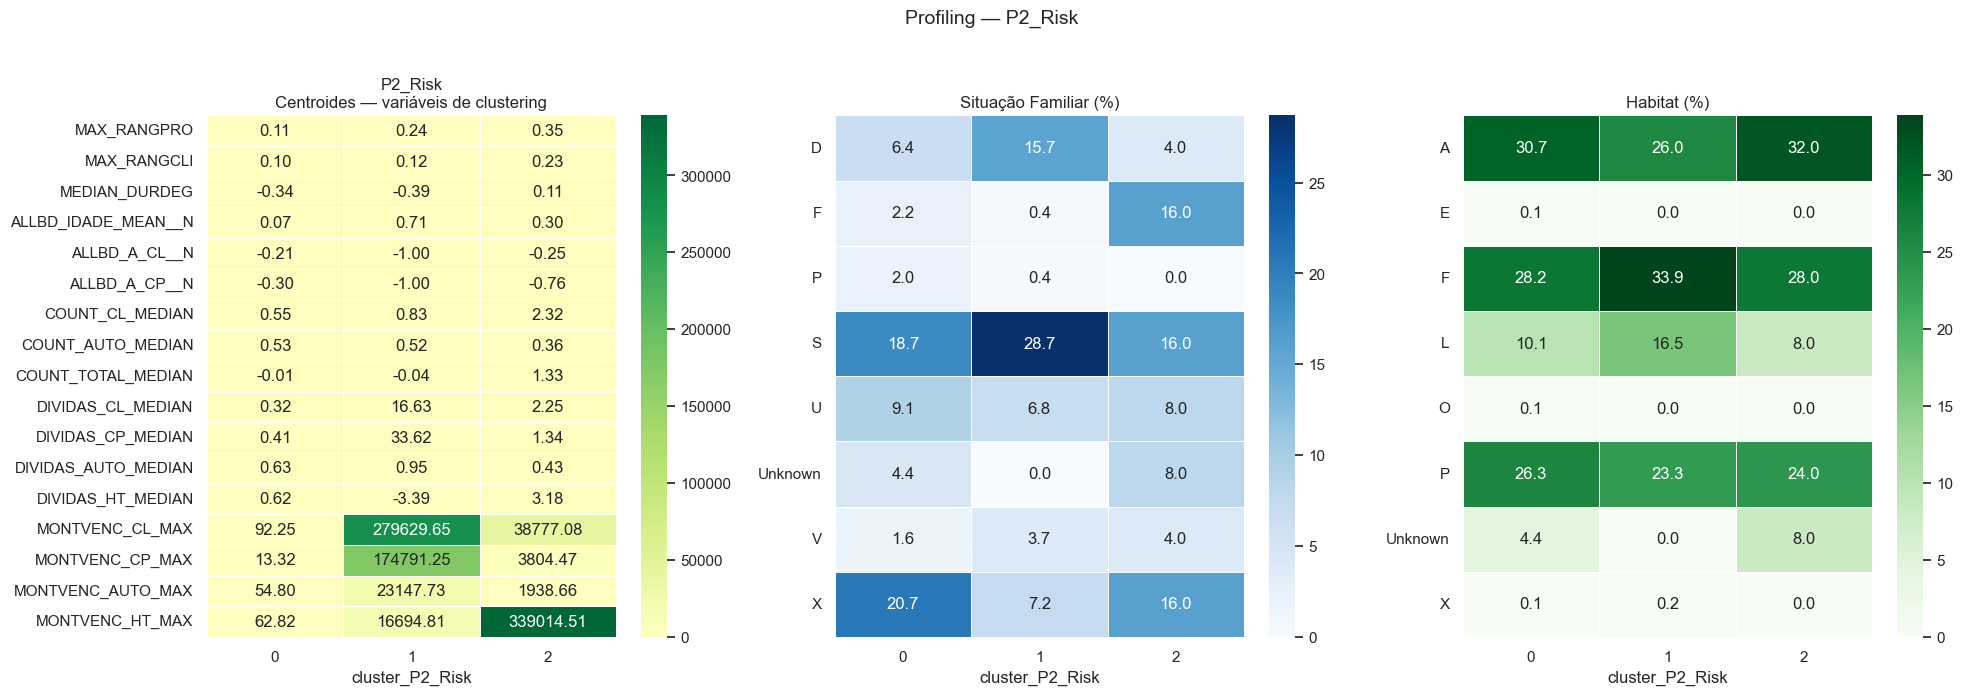


PROFILING — P3_History

── Distribuição ──
  Cluster 0:   74,729 (54.8%)
  Cluster 1:   20,561 (15.1%)
  Cluster 2:   41,156 (30.2%)

── Centroides (variáveis de clustering) ──
cluster_P3_History              0     1     2
CLIENT_SENIORITY_YEARS     -0.320 0.086 0.876
MONTHS_SINCE_LAST_CONTRACT -0.269 0.033 0.932
ALLBD_N_Dossiers__N        -0.097 1.698 0.002

── Perfil contínuo (médias) ──
                           Cluster 0  Cluster 1  Cluster 2
-------------------------------------------------------------
  sdem_age                     -0.06       0.08       0.18
  NBENF                         0.59       0.60       0.66
  CSP                          -0.33      -0.31      -0.24

── Situação Familiar (% por cluster) ──
cluster_P3_History       0      1      2
sdem_SITFAM_D        4.600  9.100  8.400
sdem_SITFAM_F        2.600  1.900  1.700
sdem_SITFAM_P        2.400  1.800  1.400
sdem_SITFAM_S       16.200 25.100 20.200
sdem_SITFAM_U        8.500  9.800  9.800
sdem_SITFAM_Unknown  

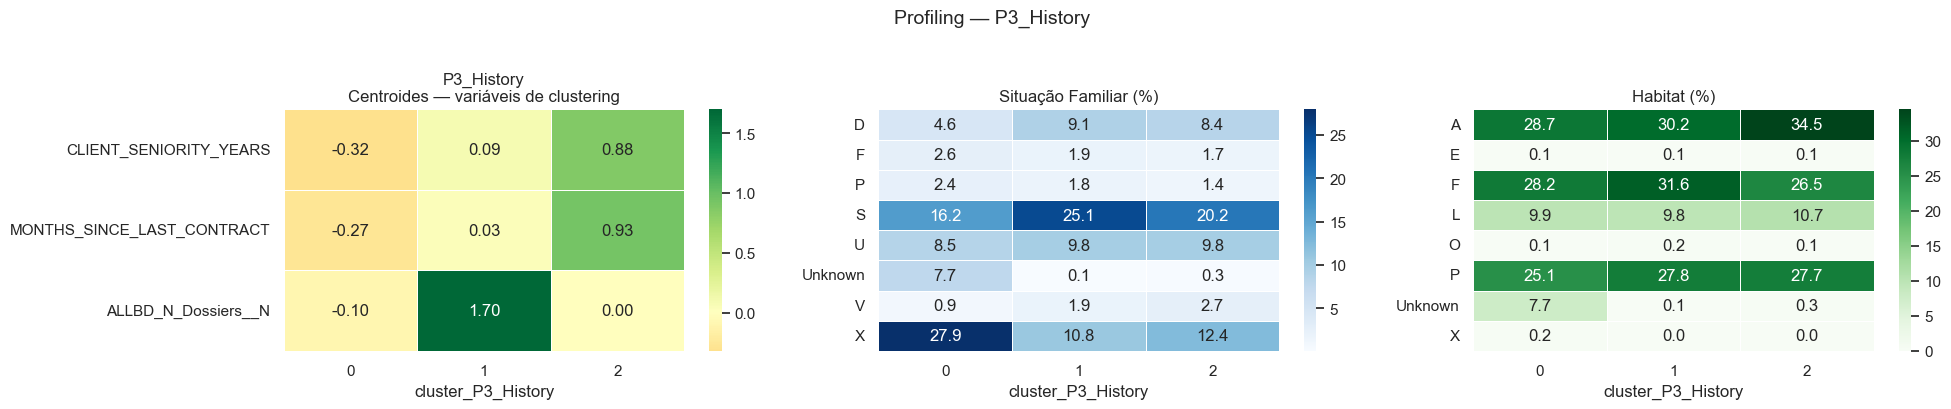


PROFILING — Combinação P1 x P2 x P3
                  n_clientes  age_media  nbenf_medio  csp_medio  sitfam_D  sitfam_F  sitfam_P  sitfam_S  sitfam_U  sitfam_Unknown  sitfam_V  sitfam_X  habitat_A  habitat_E  habitat_F  habitat_L  habitat_O  habitat_P  habitat_Unknown  habitat_X    pct
cluster_P1_P2_P3                                                                                                                                                                                                                                          
0_0_0                  52247     -0.146        0.594     -0.300     0.039     0.027     0.025     0.174     0.086           0.091     0.008     0.302      0.250      0.001      0.310      0.110      0.001      0.235            0.091      0.002 38.300
0_0_2                  27086      0.086        0.637     -0.199     0.077     0.020     0.016     0.228     0.105           0.004     0.027     0.149      0.301      0.001      0.300      0.122      0.001      

In [52]:

# ── Configuração das colunas de profiling ─────────────────────────────────────

# Variáveis contínuas de profiling
continuous_profiling = [
    'sdem_age', 'NBENF', 'CSP'
]

# Variáveis de clustering por perspetiva
all_feature_cols = p1_cols + p2_cols + p3_cols

# Dummies SITFAM e HABITAT para profiling
sitfam_cols  = ['sdem_SITFAM_D', 'sdem_SITFAM_F', 'sdem_SITFAM_P', 'sdem_SITFAM_S',
                'sdem_SITFAM_U', 'sdem_SITFAM_Unknown', 'sdem_SITFAM_V', 'sdem_SITFAM_X']

habitat_cols = ['sdem_HABITAT_A', 'sdem_HABITAT_E', 'sdem_HABITAT_F', 'sdem_HABITAT_L',
                'sdem_HABITAT_O', 'sdem_HABITAT_P', 'sdem_HABITAT_Unknown', 'sdem_HABITAT_X']

# ── Função de profiling completo ──────────────────────────────────────────────
def full_profile(df, cluster_col, feature_cols, name):
    print(f"\n{'='*60}")
    print(f"PROFILING — {name}")
    print(f"{'='*60}")

    valid = df.dropna(subset=[cluster_col])

    # 1. Distribuição dos clusters
    print("\n── Distribuição ──")
    for c, count in valid[cluster_col].value_counts().sort_index().items():
        pct = count / len(valid) * 100
        print(f"  Cluster {int(c)}: {count:>8,} ({pct:.1f}%)")

    # 2. Centroides das variáveis de clustering
    print("\n── Centroides (variáveis de clustering) ──")
    centroids = valid.groupby(cluster_col)[feature_cols].mean().round(3)
    print(centroids.T.to_string())

    # 3. Variáveis contínuas de profiling
    print("\n── Perfil contínuo (médias) ──")
    print(f"{'':25}", end='')
    clusters = sorted(valid[cluster_col].dropna().unique())
    for c in clusters:
        print(f"  Cluster {int(c):>1}", end='')
    print()
    print("-" * (25 + len(clusters) * 12))

    for col in continuous_profiling:
        if col in valid.columns:
            print(f"  {col:<23}", end='')
            for c in clusters:
                val = valid[valid[cluster_col] == c][col].mean()
                print(f"  {val:>9.2f}", end='')
            print()

    # 4. SITFAM — categoria dominante por cluster
    print("\n── Situação Familiar (% por cluster) ──")
    sitfam_available = [c for c in sitfam_cols if c in valid.columns]
    sitfam_profile = valid.groupby(cluster_col)[sitfam_available].mean().mul(100).round(1)
    print(sitfam_profile.T.to_string())

    # 5. HABITAT — categoria dominante por cluster
    print("\n── Habitat (% por cluster) ──")
    habitat_available = [c for c in habitat_cols if c in valid.columns]
    habitat_profile = valid.groupby(cluster_col)[habitat_available].mean().mul(100).round(1)
    print(habitat_profile.T.to_string())

    # 6. Heatmap dos centroides
    fig, axes = plt.subplots(1, 3, figsize=(20, max(4, len(feature_cols) * 0.4)))

    # Heatmap clustering features
    sns.heatmap(centroids.T, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, ax=axes[0], linewidths=0.5, cbar=True)
    axes[0].set_title(f'{name}\nCentroides — variáveis de clustering')

    # Heatmap SITFAM
    if len(sitfam_available) > 0:
        sns.heatmap(sitfam_profile.T, annot=True, fmt='.1f', cmap='Blues',
                    ax=axes[1], linewidths=0.5, cbar=True)
        axes[1].set_title('Situação Familiar (%)')
        axes[1].set_yticklabels([c.replace('sdem_SITFAM_', '') 
                                  for c in sitfam_available], rotation=0)

    # Heatmap HABITAT
    if len(habitat_available) > 0:
        sns.heatmap(habitat_profile.T, annot=True, fmt='.1f', cmap='Greens',
                    ax=axes[2], linewidths=0.5, cbar=True)
        axes[2].set_title('Habitat (%)')
        axes[2].set_yticklabels([c.replace('sdem_HABITAT_', '') 
                                  for c in habitat_available], rotation=0)

    plt.suptitle(f'Profiling — {name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# ── Correr profiling para cada perspetiva ─────────────────────────────────────
perspectives_profiling = {
    'P1_Financial': {'col': 'cluster_P1_Financial', 'features': p1_cols},
    'P2_Risk':      {'col': 'cluster_P2_Risk',      'features': p2_cols},  # ← rever amanhã
    'P3_History':   {'col': 'cluster_P3_History',   'features': p3_cols},
}

for name, config in perspectives_profiling.items():
    full_profile(
        customer,
        cluster_col=config['col'],
        feature_cols=config['features'],
        name=name
    )

# ── Profiling do cluster combinado ────────────────────────────────────────────
print(f"\n{'='*60}")
print("PROFILING — Combinação P1 x P2 x P3")
print(f"{'='*60}")

combo_profile = customer.groupby('cluster_P1_P2_P3').agg(
    n_clientes      = ('cluster_P1_P2_P3', 'count'),
    age_media       = ('sdem_age', 'mean'),
    nbenf_medio     = ('NBENF', 'mean'),
    csp_medio       = ('CSP', 'mean'),
    **{col.replace('sdem_SITFAM_', 'sitfam_'): 
       (col, 'mean') for col in sitfam_cols if col in customer.columns},
    **{col.replace('sdem_HABITAT_', 'habitat_'): 
       (col, 'mean') for col in habitat_cols if col in customer.columns},
).round(3)

combo_profile['pct'] = (combo_profile['n_clientes'] / len(customer) * 100).round(1)
combo_profile = combo_profile.sort_values('n_clientes', ascending=False)

print(combo_profile.to_string())